In [4]:
 !pip install ultralytics

from ultralytics import YOLO

# Load a model
model = YOLO("yolov8n-cls.pt")

# Display model information (optional)
model.info()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8n-cls summary: 56 layers, 2,719,288 parameters, 0 gradients, 4.4 GFLOPs


(56, 2719288, 0, 4.383948800000001)

In [5]:
dataset_path = "/content/drive/MyDrive/yolodataset"



In [6]:
model.train(data=dataset_path, epochs=10, imgsz=224, batch=16)

Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolodataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f19dd4abb30>
curves: []
curves_results: []
fitness: 1.0
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 1.0, 'metrics/accuracy_top5': 1.0, 'fitness': 1.0}
save_dir: PosixPath('/content/runs/classify/train')
speed: {'preprocess': 0.0007324207737145434, 'inference': 14.920130857527461, 'loss': 5.9046601351817446e-05, 'postprocess': 0.00012829959947768086}
task: 'classify'
top1: 1.0
top5: 1.0

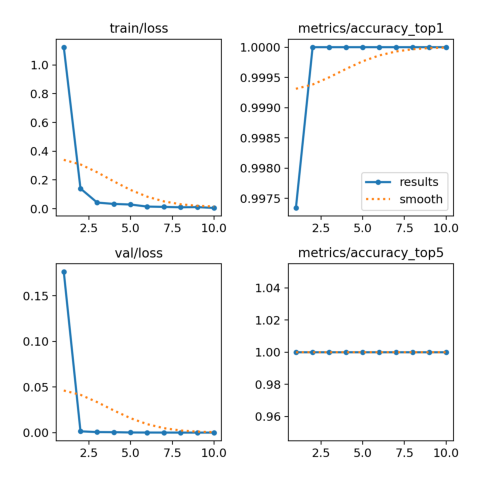

In [7]:
import matplotlib.pyplot as plt
import cv2

# Path to your results.png (adjust trainX to your run number)
img_path = "/content/runs/classify/train/results.png"

# Load and display
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()


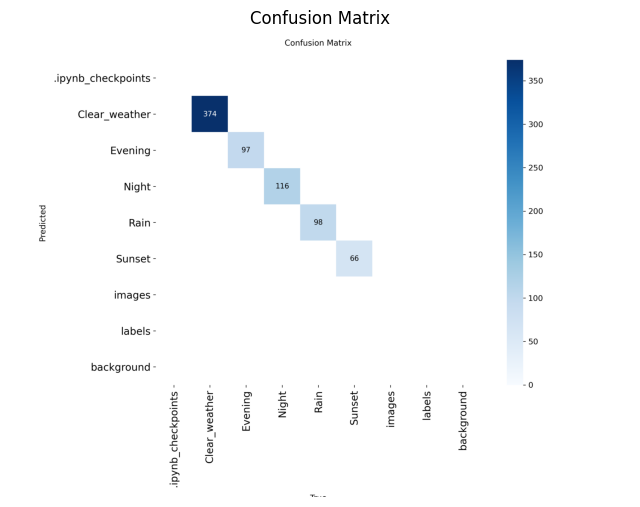

In [26]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to confusion matrix image
img_path = "/content/runs/classify/train/confusion_matrix.png"

# Load and show image
img = mpimg.imread(img_path)
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()


In [8]:
import os
import shutil
import random

base = "/content/drive/MyDrive/yolodataset"
classes = ["Clear_weather", "Night", "Sunset", "Rain", "Evening"]

# Create folders
for split in ["train", "val"]:
    for cls in classes:
        os.makedirs(f"{base}/images/{split}/{cls}", exist_ok=True)
        os.makedirs(f"{base}/labels/{split}/{cls}", exist_ok=True)

# Move images
for cls in classes:
    imgs = [f for f in os.listdir(f"{base}/{cls}") if f.lower().endswith((".jpg",".jpeg",".png"))]
    random.shuffle(imgs)
    split_idx = int(0.8 * len(imgs))

    train_imgs = imgs[:split_idx]
    val_imgs = imgs[split_idx:]

    for img in train_imgs:
        shutil.move(f"{base}/{cls}/{img}", f"{base}/images/train/{cls}/{img}")
    for img in val_imgs:
        shutil.move(f"{base}/{cls}/{img}", f"{base}/images/val/{cls}/{img}")



In [9]:
import random
from glob import glob
import torch
import torch.nn as nn
class CBAMBlock(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super().__init__()
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_planes, in_planes//ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes//ratio, in_planes, 1, bias=False),
            nn.Sigmoid()
        )
        self.sa = nn.Sequential(
            nn.Conv2d(2,1,kernel_size,padding=kernel_size//2,bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Channel attention
        x = self.ca(x) * x
        # Spatial attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out,_ = torch.max(x, dim=1, keepdim=True)
        x = self.sa(torch.cat([avg_out,max_out], dim=1)) * x
        return x

# Generate labels
for split in ["train", "val"]:
    for cls_id, cls in enumerate(classes):
        img_folder = f"{base}/images/{split}/{cls}"
        label_folder = f"{base}/labels/{split}/{cls}"
        os.makedirs(label_folder, exist_ok=True)

        images = glob(f"{img_folder}/*.jpg") + glob(f"{img_folder}/*.png")
        for img_path in images:
            img_name = os.path.basename(img_path).rsplit('.', 1)[0] + ".txt"
            label_path = os.path.join(label_folder, img_name)
            # Dummy label (full image)
            with open(label_path, "w") as f:
                f.write(f"{cls_id} 0.5 0.5 0.9 0.9\n")


In [10]:
!ls /content/drive/MyDrive/yolodataset/images/train


Clear_weather  Evening	Night  Rain  Sunset


In [11]:
%%writefile /content/drive/MyDrive/yolodataset/data.yaml
train: /content/drive/MyDrive/yolodataset/images/train
val: /content/drive/MyDrive/yolodataset/images/val

nc: 5
names: ['Clear_weather', 'Night', 'Sunset', 'Rain', 'Evening']


Overwriting /content/drive/MyDrive/yolodataset/data.yaml


In [12]:
data_yaml = f"""
train: {base}/images/train
val: {base}/images/val

nc: {len(classes)}
names: {classes}
"""

with open(f"{base}/data.yaml", "w") as f:
    f.write(data_yaml)


In [13]:
model = YOLO("yolov8n.pt")  # detection model

# Inject CBAM into first few layers of backbone (example)
for i, layer in enumerate(model.model.model[:3]):  # adjust layers as needed
    if isinstance(layer, nn.Conv2d):
        model.model.model[i] = nn.Sequential(layer, CBAMBlock(layer.out_channels))


In [14]:
model.train(
    data=f"{base}/data.yaml",
    epochs=5,
    imgsz=640,
    batch=16
)


Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolodataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f19bd840650>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [19]:
import pandas as pd

# Load the results.csv from the object detection training run
csv_path = "/content/runs/detect/train/results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()  # strip spaces
print("Available columns:\n", df.columns.tolist())

Available columns:
 ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


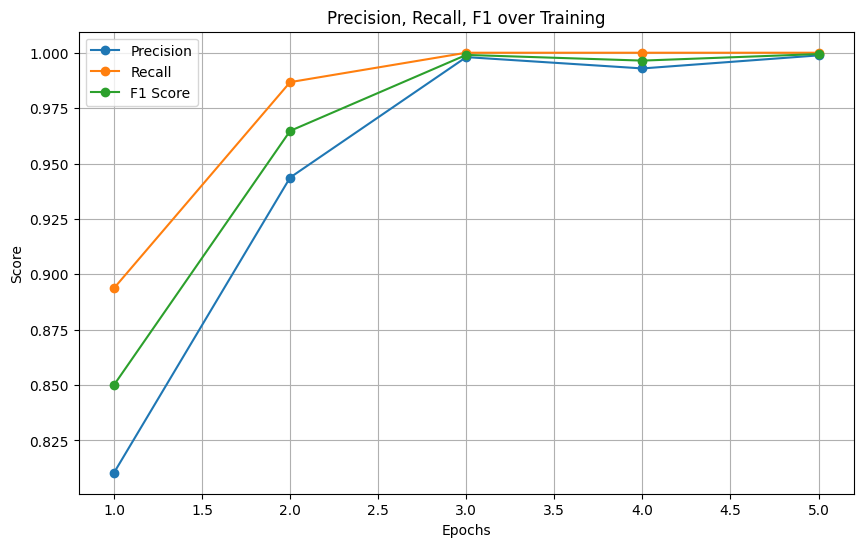

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision", marker="o")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall", marker="o")

# Calculate and plot F1 score
df["f1"] = 2 * (df["metrics/precision(B)"] * df["metrics/recall(B)"]) / (
    df["metrics/precision(B)"] + df["metrics/recall(B)"]
)
plt.plot(df["epoch"], df["f1"], label="F1 Score", marker="o")

plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("Precision, Recall, F1 over Training")
plt.legend()
plt.grid(True)
plt.show()

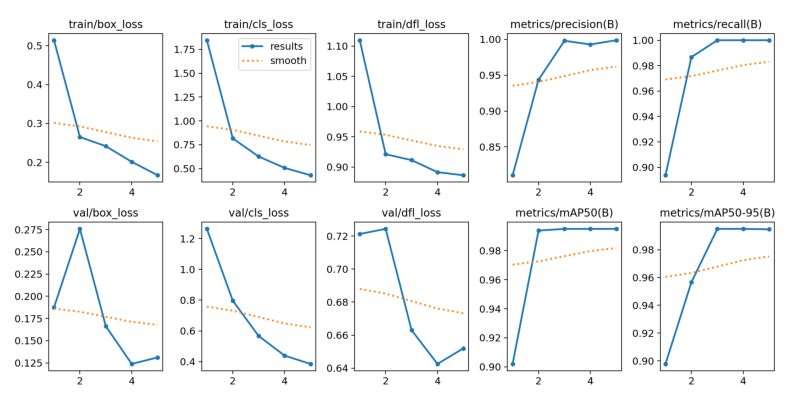

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to YOLO training results
img_path = "/content/runs/detect/train/results.png"

# Load and plot
img = mpimg.imread(img_path)
plt.figure(figsize=(10,7))
plt.imshow(img)
plt.axis("off")
plt.show()


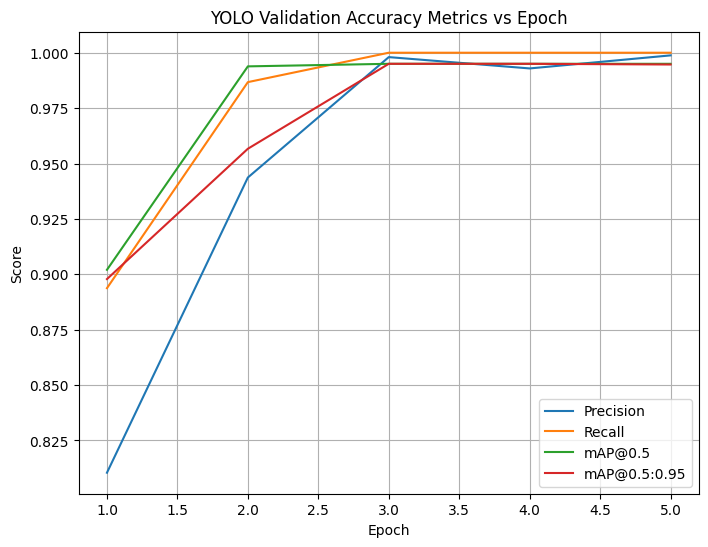

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training results
df = pd.read_csv("/content/runs/detect/train/results.csv")

plt.figure(figsize=(8,6))

# Plot validation metrics
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("YOLO Validation Accuracy Metrics vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


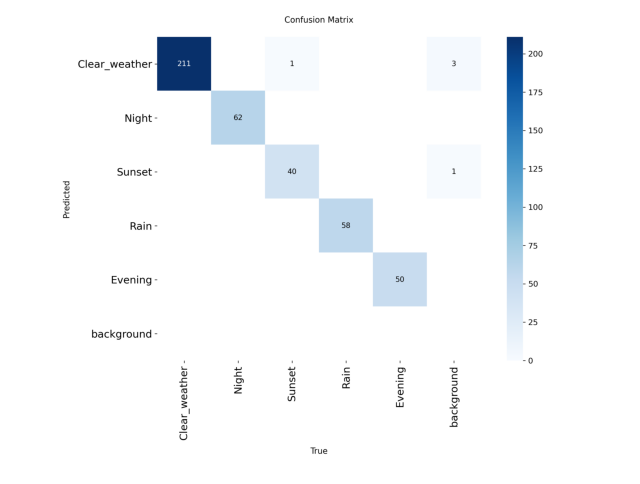

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to confusion matrix image
img_path = "/content/runs/detect/train/confusion_matrix.png"

# Load and display
img = mpimg.imread(img_path)
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()


Downloading...
From: https://drive.google.com/uc?id=1EVsBT1f3zRwq58JXEjpRz7aeuDvO-mz_
To: /content/drive/MyDrive/images.jpeg
100%|██████████| 9.40k/9.40k [00:00<00:00, 3.30MB/s]


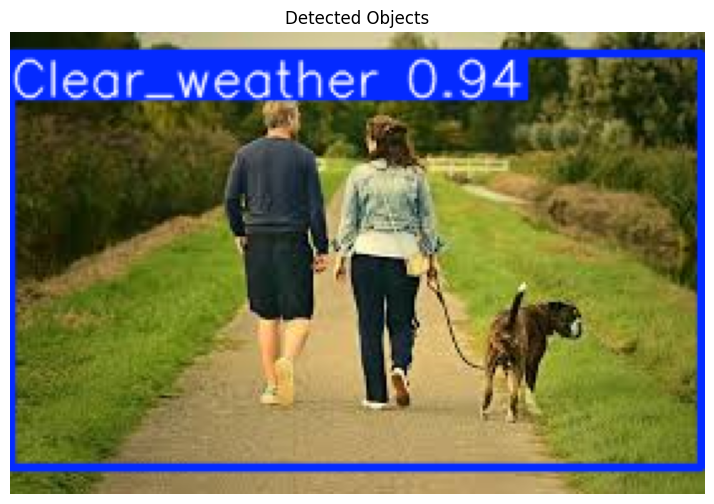

In [22]:
import gdown
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Download the shared file from Google Drive
file_id = "1EVsBT1f3zRwq58JXEjpRz7aeuDvO-mz_"
img_dl_path = "/content/drive/MyDrive/images.jpeg"
gdown.download(f"https://drive.google.com/uc?id={file_id}", img_dl_path, quiet=False)

# 2. Load your trained YOLO detection model
model = YOLO("/content/runs/detect/train/weights/best.pt")  # use DETECTION weights

# 3. Run detection
results = model.predict(img_dl_path, conf=0.25, save=False, verbose=False)

# 4. Plot results
if len(results) > 0:
    img_with_boxes = results[0].plot()  # Draw bounding boxes + labels
    img_with_boxes = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(img_with_boxes)
    plt.axis("off")
    plt.title("Detected Objects")
    plt.show()
else:
    print("No objects detected in the image.")
